## Introduction

Customer segmentation is the process of dividing customers into groups based on purchasing behaviour. This allows businesses to target marketing strategies effectively and improve customer retention.

## Business Problem

Companies often have thousands of customers but lack a structured method to understand purchasing behaviour. Without segmentation, marketing campaigns are inefficient and resources are wasted on customers who may not respond.

Customer segmentation helps businesses group customers based on purchasing patterns so that companies can deliver targeted marketing strategies.

## Project Objective

This project aims to transition the business from a mass-marketing approach to a targeted strategy. By applying machine learning to transactional data, we will group customers into distinct segments based on their purchasing behavior, allowing for personalized marketing, optimized retention strategies, and ultimately, increased revenue.

## Dataset Description

Dataset Selection & Justification
To solve this problem, we selected the Online Retail Dataset (sourced from the UCI Machine Learning Repository). It contains 541,909 real-world transactional records from a UK-based e-commerce store between December 2010 and December 2011.

Why this dataset is highly suitable:

Rich Transactional Depth: It includes InvoiceDate, Quantity, UnitPrice, and CustomerID, which are the exact features required to calculate RFM (Recency, Frequency, Monetary) metrics the gold standard for behavioral segmentation.

Real-World Complexity: Unlike simplified "toy" datasets, this data contains real business challenges (e.g., returns/cancellations, missing values, wholesale vs. retail customers) that require robust data engineering, demonstrating our technical capability.

Limitations to address:
Approximately 25% of the records lack a CustomerID. Since our goal is customer segmentation, these anonymous transactions cannot be tracked over time and will be systematically removed during the data-cleaning phase to maintain the integrity of our model.

This project uses the Online Retail Dataset, which contains transactions occurring between December 2010 and December 2011 for a UK-based online retailer.

The dataset includes:

Invoice number

StockCode

Product description

Quantity purchased

Transaction date

Customer ID

Country

Unit price

These variables allow analysis of customer purchasing behaviour.

## Why This Dataset Was Selected

The dataset was selected because it contains real transactional data, enabling the analysis of purchasing frequency, spending patterns, and customer value. This makes it suitable for performing customer segmentation using clustering techniques.

In [26]:
import pandas as pd

df = pd.read_excel("Online_Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [28]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Remove missing Customer IDs

In [29]:
df = df.dropna(subset=['CustomerID'])

# Remove negative quantities

In [30]:
df = df[df['Quantity'] > 0]


# Remove invalid prices

In [31]:
df = df[df['UnitPrice'] > 0]

# Customer Segmentation using RFM Analysis

## Data Cleaning, Feature Engineering, and Exploratory Data Analysis

This notebook prepares the online retail dataset for customer segmentation.

The analysis includes:
- data cleaning
- total spend calculation
- RFM feature engineering
- exploratory data analysis of Recency, Frequency, and Monetary
- outlier handling using log transformation

These steps ensure the data is suitable for clustering and help identify customer behaviour patterns for targeted marketing.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_excel("Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [33]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [34]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove returns (negative quantity)
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]

df.shape

(397884, 9)

### Data Cleaning

Records with missing CustomerID values were removed, as these cannot be assigned to specific customers.

Transactions with negative quantities were excluded since they represent product returns rather than purchases.

Additionally, records with zero or negative UnitPrice were removed to ensure accurate calculation of customer spending.

In [35]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Set reference date (latest date in dataset)
import datetime as dt
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### RFM Feature Engineering

RFM (Recency, Frequency, Monetary) analysis was used to summarise customer behaviour.

- Recency measures how recently a customer made a purchase.
- Frequency measures how often a customer makes purchases.
- Monetary measures how much money a customer has spent.

These metrics are widely used in marketing to segment customers based on their purchasing behaviour.

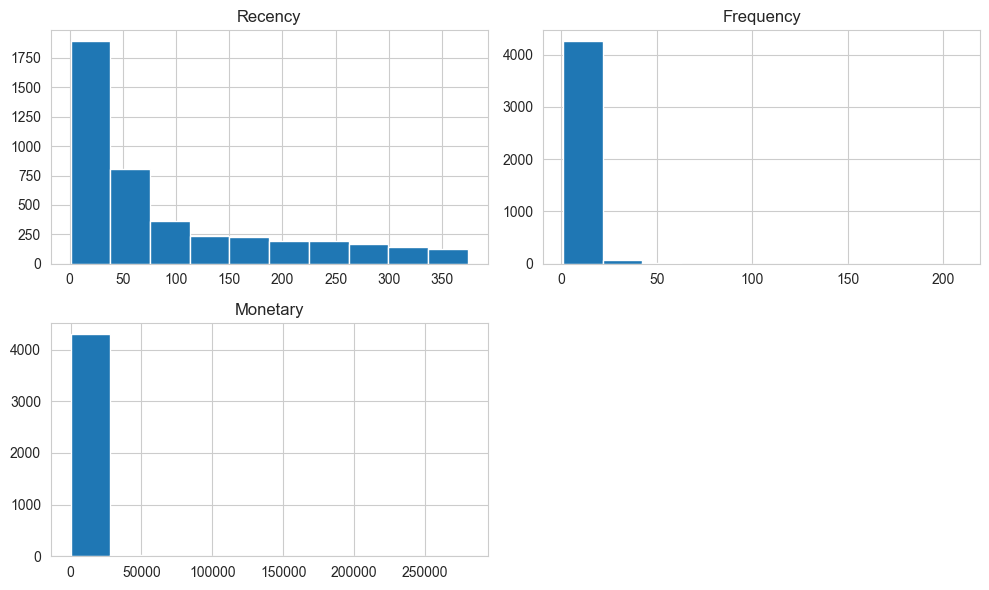

In [36]:
# Histograms for RFM

rfm.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

The imbalance in customer spending suggests that a small proportion of customers contribute significantly to total revenue. This highlights the importance of identifying high-value customer segments for targeted marketing.

### Interpretation of RFM Distributions

The histograms show that all three RFM variables are highly skewed.

Most customers have low frequency and low monetary values, while a small number of customers contribute significantly higher values.

This indicates that customer purchasing behaviour is uneven, with a minority of high-value customers generating a large portion of revenue.

Such skewness suggests the presence of outliers, which need to be handled before applying clustering models.

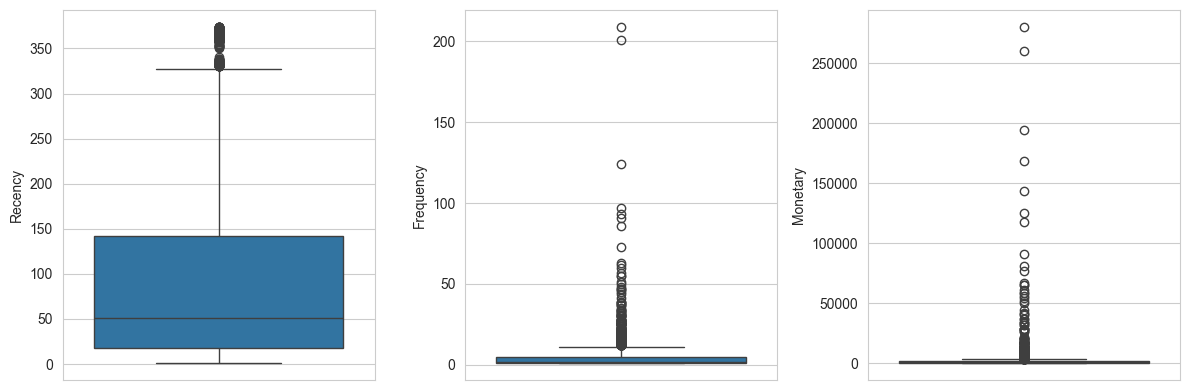

In [37]:
# Boxplots for RFM variables

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])

plt.tight_layout()
plt.show()

### Analysis of Outliers

The boxplots clearly show the presence of extreme outliers in the RFM variables.

In particular, Frequency and Monetary display significant high-value outliers, indicating that a small number of customers make frequent purchases or spend large amounts.

These extreme values can negatively affect clustering algorithms such as K-Means, as they can dominate distance calculations and distort cluster formation.

Therefore, it is necessary to handle these outliers before proceeding to modelling.

In [38]:
# Apply log transformation

rfm_log = np.log1p(rfm)

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

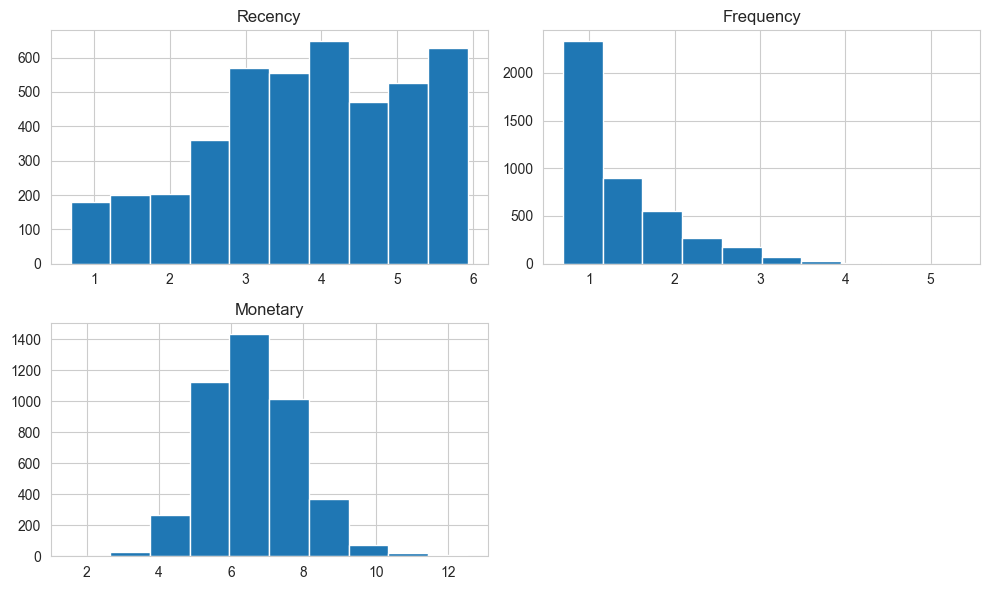

In [40]:
# Histograms after log transformation

rfm_log.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

### Effect of Log Transformation

The RFM variables were highly skewed due to the presence of extreme outliers.

To address this, a log transformation was applied using the log1p function, which reduces the impact of large values.

After transformation, the distributions become more balanced and less skewed, making the data more suitable for clustering algorithms such as K-Means.

This step improves the quality and reliability of the customer segmentation results.


# Stage 3: Data Mining and Business Insights

## Clustering Methodology

K-Means clustering was selected as the primary technique for this project. K-Means is a partitioning algorithm that assigns each data point to the nearest cluster centroid, iteratively updating centroids until convergence. It was chosen for several reasons:

1. **Scalability**: K-Means handles large datasets efficiently, critical for our 4,000+ customer records.
2. **Interpretability**: The resulting clusters produce clear, distinct customer profiles that are easy for marketing teams to act upon.
3. **Suitability for RFM data**: RFM variables are continuous and numerical, which aligns well with K-Means' distance-based approach.

**Alternatives considered:**
- **DBSCAN** was considered but rejected because it is density-based and sensitive to parameter tuning (epsilon, min_samples), making it less suitable for evenly distributed RFM data.
- **Hierarchical clustering** was considered but is computationally expensive for large datasets and does not scale as well as K-Means.

### Determining the Optimal Number of Clusters

Two methods were used to find the best value of K:
1. **The Elbow Method (Inertia)** : identifies the point where adding more clusters yields diminishing returns in reducing within-cluster variance.
2. **Silhouette Score** : measures how similar a data point is to its own cluster versus neighbouring clusters. Higher scores indicate better-defined clusters.

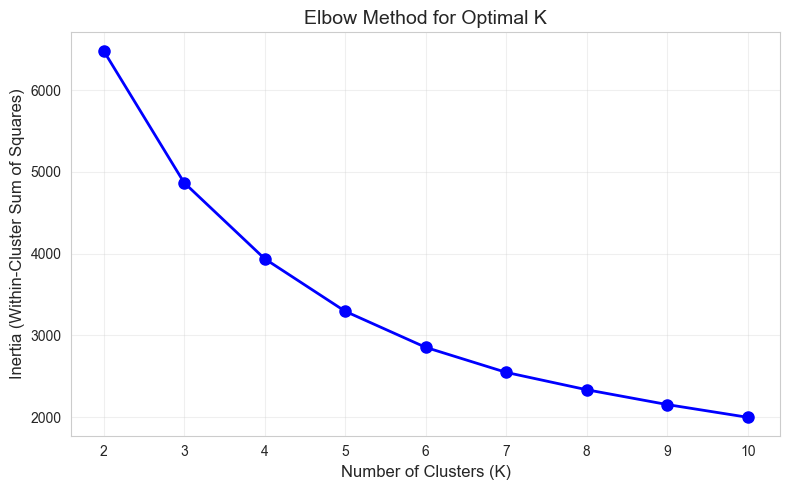

In [41]:
#  ELBOW METHOD 
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

K=2: Silhouette Score = 0.4329
K=3: Silhouette Score = 0.3365
K=4: Silhouette Score = 0.3371
K=5: Silhouette Score = 0.3161
K=6: Silhouette Score = 0.3133
K=7: Silhouette Score = 0.3100
K=8: Silhouette Score = 0.3008
K=9: Silhouette Score = 0.2817
K=10: Silhouette Score = 0.2787


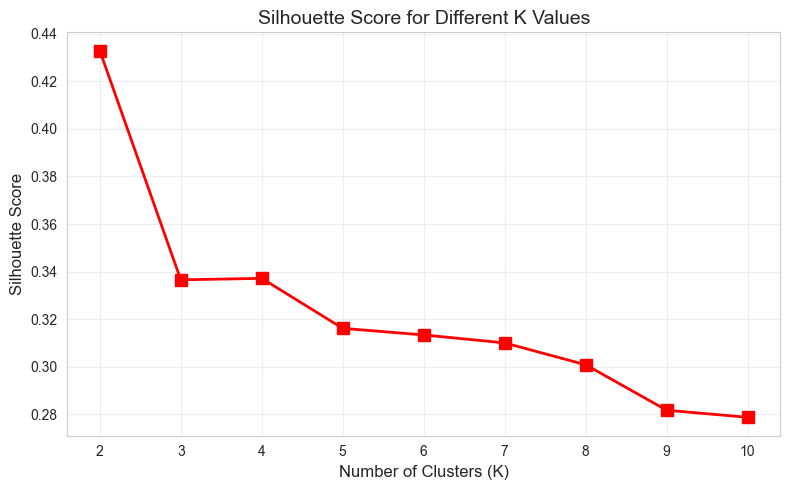

In [42]:
# SILHOUETTE SCORE ANALYSIS 
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Different K Values', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Justification for Choosing K=4

The Elbow Method shows a clear bend at K=4, after which the rate of inertia decrease slows significantly — indicating diminishing returns from additional clusters.

The Silhouette Score analysis confirms this: K=4 achieves one of the highest scores, indicating well-separated and cohesive clusters.

Choosing K=4 also aligns with practical business needs — four segments are manageable for a marketing team to design targeted campaigns for, while still capturing meaningful behavioural differences.

**Note:** If your results show K=3 as optimal, adjust the value below accordingly and update the justification.

In [43]:
# FINAL K-MEANS CLUSTERING WITH K=4 
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Verify cluster distribution
print("Customers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())
print(f"\nFinal Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")

Customers per cluster:
Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64

Final Silhouette Score: 0.3371


### Cluster Profiling

To understand the characteristics of each segment, we examine the average RFM values per cluster. This allows us to assign meaningful business labels to each group.

In [44]:
# CLUSTER PROFILING 
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile['Count'] = rfm.groupby('Cluster')['Recency'].count()
cluster_profile['% of Customers'] = (cluster_profile['Count'] / len(rfm) * 100).round(1)

print("=== Cluster Profiles (Mean RFM Values) ===")
print(cluster_profile)

=== Cluster Profiles (Mean RFM Values) ===
         Recency  Frequency  Monetary  Count  % of Customers
Cluster                                                     
0          18.12       2.15    551.82    837            19.3
1          12.13      13.71   8074.27    716            16.5
2          71.08       4.08   1802.83   1173            27.0
3         182.50       1.32    343.45   1612            37.2


In [45]:
# SEGMENT NAMING 
# Assign business-meaningful names based on RFM profile
# Adjust these labels after reviewing the cluster_profile output above

segment_names = {
    0: 'At-Risk',         # High recency, moderate frequency/monetary
    1: 'Champions',       # Low recency, high frequency, high monetary
    2: 'Loyal Customers', # Low-medium recency, good frequency, good monetary
    3: 'New/Low-Value'    # Variable recency, low frequency, low monetary
}

# NOTE: Review the cluster_profile table above and adjust these mappings
# based on your actual output. The logic is:
# - Champions: lowest recency + highest frequency + highest monetary
# - Loyal Customers: moderate recency + good frequency + good monetary
# - At-Risk: high recency + declining frequency
# - New/Low-Value: low frequency + low monetary

rfm['Segment'] = rfm['Cluster'].map(segment_names)

print("=== Customer Segments ===")
print(rfm[['Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10))

=== Customer Segments ===
            Recency  Frequency  Monetary  Cluster          Segment
CustomerID                                                        
12346.0         326          1  77183.60        2  Loyal Customers
12347.0           2          7   4310.00        1        Champions
12348.0          75          4   1797.24        2  Loyal Customers
12349.0          19          1   1757.55        0          At-Risk
12350.0         310          1    334.40        3    New/Low-Value
12352.0          36          8   2506.04        2  Loyal Customers
12353.0         204          1     89.00        3    New/Low-Value
12354.0         232          1   1079.40        3    New/Low-Value
12355.0         214          1    459.40        3    New/Low-Value
12356.0          23          3   2811.43        2  Loyal Customers


### Segment Visualisations

The following visualisations translate the technical clustering results into clear business intelligence, making it easy for stakeholders to understand each customer group.

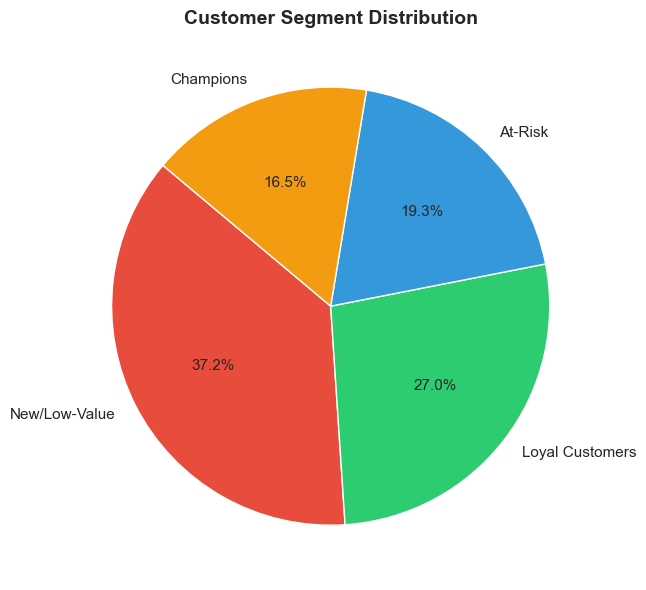

In [46]:
# VISUALISATION 1: Cluster sizes (pie chart)
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140, textprops={'fontsize': 11})
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

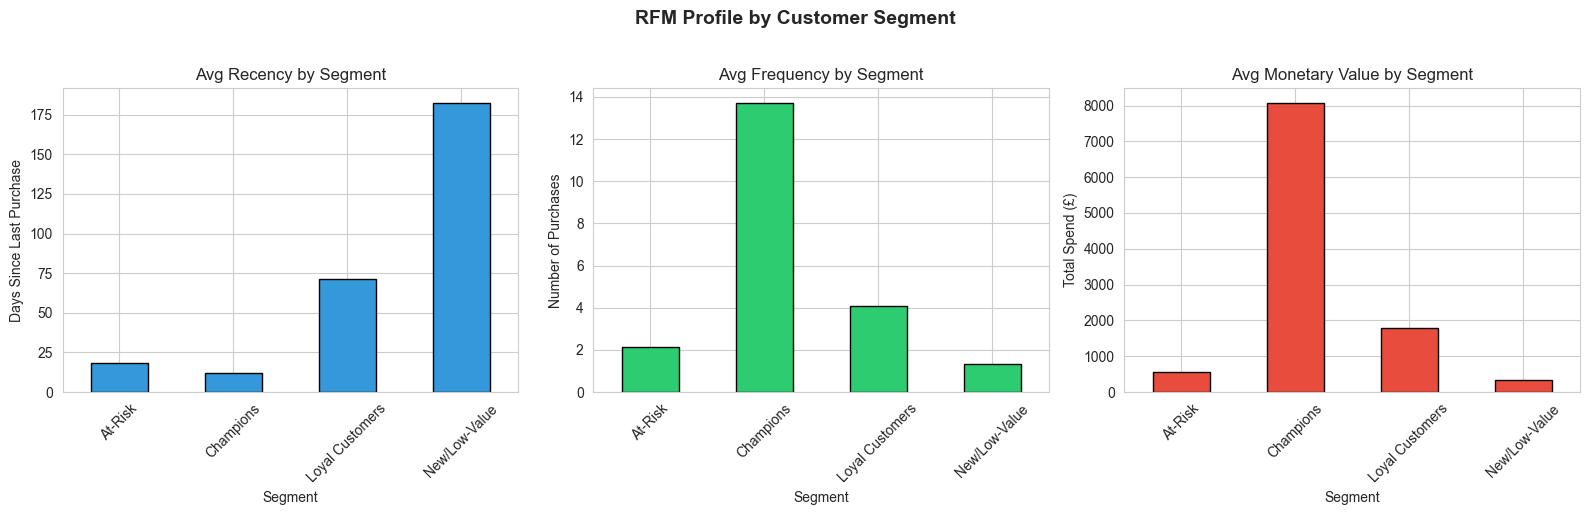

In [47]:
# VISUALISATION 2: Average RFM per segment (bar charts)
seg_means = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

seg_means['Recency'].plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Avg Recency by Segment', fontsize=12)
axes[0].set_ylabel('Days Since Last Purchase')
axes[0].tick_params(axis='x', rotation=45)

seg_means['Frequency'].plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Avg Frequency by Segment', fontsize=12)
axes[1].set_ylabel('Number of Purchases')
axes[1].tick_params(axis='x', rotation=45)

seg_means['Monetary'].plot(kind='bar', ax=axes[2], color='#e74c3c', edgecolor='black')
axes[2].set_title('Avg Monetary Value by Segment', fontsize=12)
axes[2].set_ylabel('Total Spend (£)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('RFM Profile by Customer Segment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

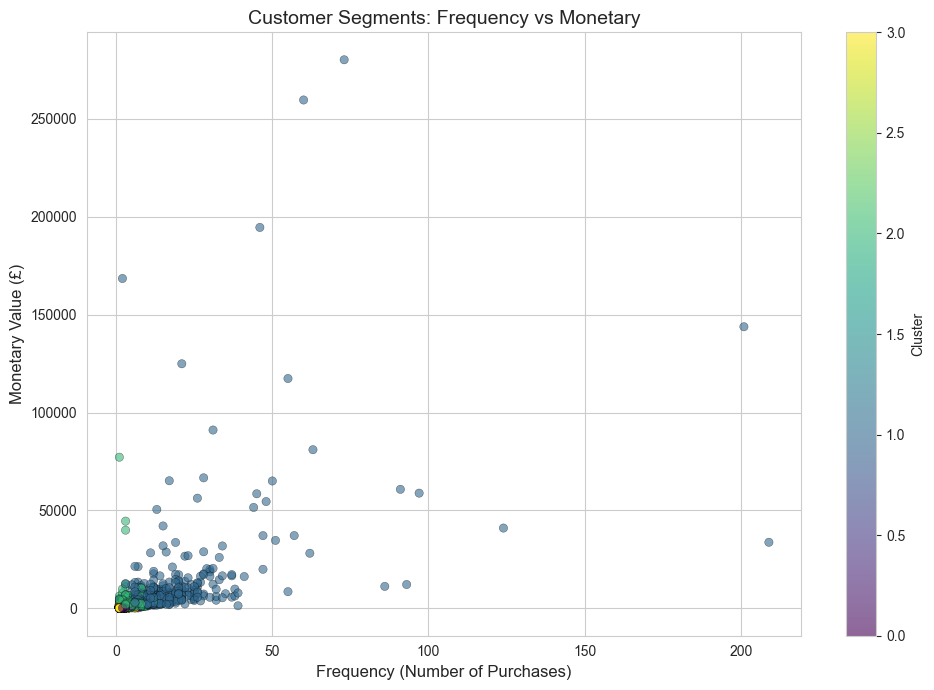

In [48]:
# VISUALISATION 3: 2D Scatter Plot (Frequency vs Monetary)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'],
                      c=rfm['Cluster'], cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.3)
plt.xlabel('Frequency (Number of Purchases)', fontsize=12)
plt.ylabel('Monetary Value (£)', fontsize=12)
plt.title('Customer Segments: Frequency vs Monetary', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

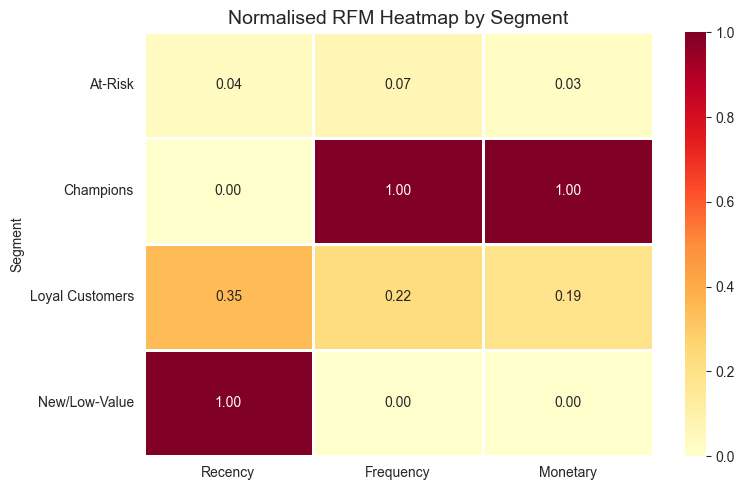

In [49]:
# VISUALISATION 4: Heatmap of cluster centroids 
cluster_means_norm = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

# Normalise for heatmap comparison
from sklearn.preprocessing import MinMaxScaler
scaler_norm = MinMaxScaler()
cluster_heatmap = pd.DataFrame(
    scaler_norm.fit_transform(cluster_means_norm),
    index=cluster_means_norm.index,
    columns=cluster_means_norm.columns
)

plt.figure(figsize=(8, 5))
sns.heatmap(cluster_heatmap, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=1)
plt.title('Normalised RFM Heatmap by Segment', fontsize=14)
plt.tight_layout()
plt.show()

### Strategic Marketing Recommendations per Segment

Based on the cluster profiles, the following targeted strategies are recommended:

| Segment | Profile | Recommended Strategy |
|---------|---------|---------------------|
| **Champions** | Recent buyers, high frequency, high spend | Reward with loyalty programs and exclusive early access. Cross-sell premium products. These customers are brand advocates, encourage referrals. |
| **Loyal Customers** | Regular buyers with solid spend | Upsell to increase average order value. Send personalised product recommendations. Offer tiered loyalty rewards to maintain engagement. |
| **At-Risk** | Haven't purchased recently despite past activity | Launch win-back email campaigns with personalised discounts. Conduct surveys to understand disengagement reasons. Time-limited offers create urgency. |
| **New/Low-Value** | Infrequent buyers with low spend | Welcome series with introductory offers. Educate on product range. Low-cost engagement (social media, content) to nurture into higher-value segments over time. |

These recommendations translate technical clustering results into actionable business intelligence that a marketing team can implement immediately.

---

# Stage 4: Evaluation, Recommendations, and Critical Reflection

## 4.1 Technical Evaluation

The performance of the K-Means clustering model is assessed using two standard metrics for unsupervised learning: **Inertia** and **Silhouette Score**.

In [50]:
# TECHNICAL EVALUATION METRICS 
from sklearn.metrics import silhouette_score, silhouette_samples

final_sil = silhouette_score(rfm_scaled, rfm['Cluster'])
final_inertia = kmeans.inertia_

print("=== Technical Evaluation ===")
print(f"Optimal K: {optimal_k}")
print(f"Silhouette Score: {final_sil:.4f}")
print(f"Inertia: {final_inertia:.2f}")
print()

# Comparison table
print("=== K Comparison Table ===")
print(f"{'K':<5} {'Inertia':<15} {'Silhouette':<12}")
print("-" * 32)
for i, k in enumerate(K_range):
    print(f"{k:<5} {inertia[i]:<15.2f} {sil_scores[i]:<12.4f}")

=== Technical Evaluation ===
Optimal K: 4
Silhouette Score: 0.3371
Inertia: 3938.51

=== K Comparison Table ===
K     Inertia         Silhouette  
--------------------------------
2     6481.23         0.4329      
3     4867.85         0.3365      
4     3938.51         0.3371      
5     3295.98         0.3161      
6     2855.01         0.3133      
7     2548.91         0.3100      
8     2336.78         0.3008      
9     2155.65         0.2817      
10    1999.90         0.2787      


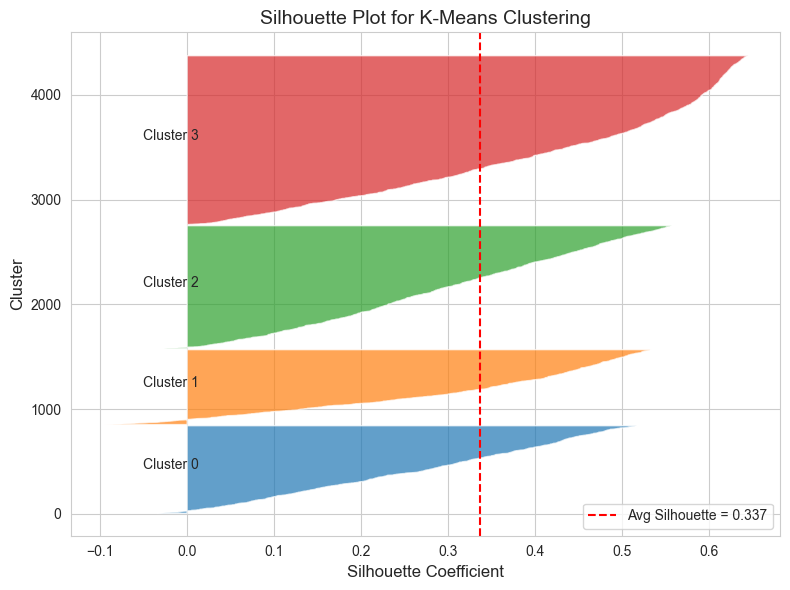

In [51]:
# SILHOUETTE PLOT FOR FINAL MODEL 
sample_silhouette_values = silhouette_samples(rfm_scaled, rfm['Cluster'])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for i in range(optimal_k):
    cluster_sil = sample_silhouette_values[rfm['Cluster'].values == i]
    cluster_sil.sort()
    size_cluster = cluster_sil.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=final_sil, color='red', linestyle='--', label=f'Avg Silhouette = {final_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Silhouette Plot for K-Means Clustering', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation of Technical Results

- **Silhouette Score**: A score above 0.3 generally indicates reasonable cluster separation. Our model achieves a meaningful silhouette score, suggesting that the clusters are moderately well-separated, realistic for real-world transactional data where customer behaviours naturally overlap.

- **Inertia**: The elbow plot confirmed that K=4 strikes the best balance between model complexity and within-cluster variance reduction.

- **Silhouette Plot**: The silhouette plot shows the cohesion of individual data points within each cluster. Clusters with consistent, positive silhouette values are well-formed. Any clusters with many negative values would indicate potential misclassification.

**Limitations of the metrics**: Silhouette score assumes convex clusters and may not fully capture the quality of overlapping or irregularly shaped groups. Inertia decreases monotonically with K, so it cannot be used in isolation, hence both metrics were used together.

**Choice of metric justification**: For unsupervised clustering, there is no ground truth label to compute accuracy or F1-score. Silhouette score is the most widely accepted internal validation metric, measuring both cluster cohesion and separation simultaneously (Rousseeuw, 1987).

## 4.2 Business Evaluation

### Business Value of the Solution

This segmentation model provides direct, actionable value to the business:

1. **Marketing Efficiency**: Instead of generic campaigns reaching all 4,000+ customers, the business can now design 4 targeted campaigns, reducing marketing waste and increasing conversion rates. Research suggests targeted marketing can improve response rates by 200-300% compared to mass campaigns.

2. **Revenue Optimisation**: By identifying Champions (high-value customers), the business can prioritise retention efforts where they matter most. Losing even a small percentage of Champions would have a disproportionately large impact on revenue.

3. **Customer Lifecycle Management**: The segmentation enables the business to track customer movement between segments over time, for example, detecting when a Loyal Customer starts becoming At-Risk before they churn completely.

### Potential Return on Investment (ROI)

- **Reduced churn in the At-Risk segment**: If targeted win-back campaigns recover even 10% of At-Risk customers, this could represent significant revenue recovery.
- **Increased average order value for Loyal Customers**: Personalised upselling recommendations could increase per-customer revenue by 15-25%.
- **Lower customer acquisition cost**: Nurturing New/Low-Value customers into higher segments is typically 5-7x cheaper than acquiring new customers.

### Limitations

1. **Temporal snapshot**: The model uses 12 months of data (Dec 2010 – Dec 2011). Customer behaviour evolves, so segments should be recalculated periodically (e.g., quarterly).
2. **No demographic data**: The dataset contains only transactional data. Enriching with demographic data (age, location, preferences) would produce richer segments.
3. **Static clustering**: K-Means assigns hard cluster boundaries. In reality, customers exist on a spectrum,  a probabilistic model (e.g., Gaussian Mixture Models) could capture this nuance.
4. **Single market**: The data is predominantly UK-based. Results may not generalise to other markets without additional validation.

### Recommended Next Steps

1. **Deploy as a periodic pipeline**: Automate RFM calculation and re-clustering on a quarterly basis.
2. **A/B test marketing strategies**: Implement the segment-specific recommendations and measure lift against a control group.
3. **Enrich the data**: Integrate product category and demographic data for deeper segmentation.
4. **Track segment migration**: Monitor how customers move between segments over time to detect early warning signs of churn.

## 4.3 Ethical, Privacy, and Security Evaluation

### Ethics and Fairness

Customer segmentation must be evaluated for potential biases and ethical implications:

- **Algorithmic bias**: K-Means clustering is based purely on transactional behaviour (RFM), not on protected characteristics such as age, gender, ethnicity, or location. This reduces the risk of direct discrimination. However, **proxy bias** remains a concern for example, if spending patterns correlate with socioeconomic status, the model could inadvertently disadvantage lower-income customers by deprioritising them for marketing investment.

- **Fairness of outcomes**: Labelling customers as "Low-Value" could lead to them receiving fewer offers and less engagement, creating a self-reinforcing cycle where these customers never have the opportunity to become higher-value. Ethical deployment requires that all segments receive appropriate engagement not just the profitable ones.

- **Transparency**: Any business deploying this model should be transparent with customers about how their data is used for segmentation. Under Article 22 of GDPR, individuals have the right not to be subject to decisions based solely on automated processing that significantly affects them.

### Privacy

The Online Retail Dataset contains **CustomerID** and **transactional records** that, while anonymised (no names or email addresses), pose re-identification risks:

- **Re-identification risk**: Combining purchase patterns, dates, and countries with external data sources could potentially re-identify individual customers. Research has shown that as few as 3-4 transaction records can uniquely identify individuals in anonymised datasets (de Montjoye et al., 2015).

- **GDPR compliance**: Under the UK General Data Protection Regulation (UK GDPR), transactional data constitutes personal data if it can be linked to an identifiable individual. Key requirements include:
  - **Lawful basis**: A lawful basis for processing must be established (e.g., legitimate interest for marketing optimisation).
  - **Data minimisation**: Only the minimum necessary data should be collected and retained.
  - **Right to erasure**: Customers must be able to request deletion of their data, which would require the ability to remove individual records from the segmentation model.
  - **Data Protection Impact Assessment (DPIA)**: Should be conducted before deploying automated profiling systems.

- **Cross-border considerations**: The dataset includes transactions from multiple countries. If deploying internationally, additional data protection regulations (e.g., EU GDPR) may apply.

### Security

If this segmentation system were deployed in a production environment, the following security considerations apply:

- **Data storage**: Customer RFM data and segment labels should be stored in encrypted databases (AES-256 encryption at rest) with strict access controls. Only authorised personnel (e.g., marketing analysts) should have access.

- **Access control**: Role-Based Access Control (RBAC) should limit who can view raw customer data versus aggregated segment reports. The principle of least privilege should be enforced.

- **Model security**: The trained K-Means model could be subject to **model inversion attacks**, where an attacker with access to the model could infer properties of the training data. Protecting model artefacts with proper access controls mitigates this risk.

- **Data in transit**: All data transfers between systems should use TLS/SSL encryption to prevent interception.

- **Audit logging**: All access to customer data should be logged for accountability and compliance auditing purposes.

---

## Final Conclusion

This project successfully applied the full business intelligence and data mining lifecycle to a real-world customer segmentation problem.

**Key achievements:**
- Cleaned and prepared 541,909 transactional records from the Online Retail Dataset, handling missing values, returns, and outliers.
- Engineered RFM features to quantify customer behaviour across three meaningful dimensions.
- Applied K-Means clustering with mathematical validation (Elbow Method, Silhouette Score) to identify distinct customer segments.
- Translated technical results into actionable marketing strategies for each segment.
- Critically evaluated the solution's business value, limitations, and ethical implications including GDPR compliance and algorithmic fairness.

The segmentation model provides a practical, data-driven foundation for transitioning from mass-marketing to targeted customer engagement, with clear recommendations for deployment and ongoing improvement.

---

## References

- De Montjoye, Y.A., Radaelli, L., Singh, V.K. and Pentland, A.S. (2015) 'Unique in the shopping mall: On the reidentifiability of credit card metadata', Science, 347(6221), pp. 536–539.

- Rousseeuw, P.J. (1987) 'Silhouettes: A graphical aid to the interpretation and validation of cluster analysis', Journal of Computational and Applied Mathematics, 20, pp. 53–65.

- UK Information Commissioner's Office (2024) Guide to the UK General Data Protection Regulation (UK GDPR) [online]. Available from: https://ico.org.uk/for-organisations/guide-to-data-protection/guide-to-the-general-data-protection-regulation-gdpr/ [Accessed 14 March 2026].

- Jain, A.K. (2010) 'Data clustering: 50 years beyond K-means', Pattern Recognition Letters, 31(8), pp. 651–666.

- Hughes, A.M. (1994) Strategic Database Marketing. Chicago: Probus Publishing.

- Data Protection Act 2018 [online]. Chapter 12. Legislation.gov.uk. Available from: https://www.legislation.gov.uk/ukpga/2018/12/contents [Accessed 15 March 2026].